## Objectives
- look at correlations
- Use log function to transform the data
- Handle the duplicates
- Handle missing values
- Standardize and normalize the data
- Handle the outliers

In [5]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt # matplotlib inline
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import norm
from scipy import stats

#### Retrieving data via API call

In [6]:
import requests

# url to the data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/Ames_Housing_Data1.tsv"
filename = "Ames_Housing_Data.tsv"
response = requests.get(url)
response

<Response [200]>

In [8]:
# write content into a file
with open(filename, 'wb') as f:
    f.write(response.content)

In [9]:
# read the data 
housing = pd.read_csv(filename, sep='\t')
housing.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000


## Correlations
- Pair plots
- Scatter plots
- Heat maps
- Correlation matrices
`.corr()` function is based on pearson correlation coefficient. It can only be measured on the numerical attributes

In [10]:
# select only numeric attributes
housing_num = housing.select_dtypes(include=['float64', 'int64'])
housing_num_corr = housing_num.corr()
housing_num_corr

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.174064,0.012307,-0.009185,0.029680,-0.048436,-0.010749,-0.052070,-0.074823,-0.030924,...,-0.011828,0.016220,0.028105,-0.024902,0.004473,0.052528,-0.006027,0.133557,-0.976016,-0.031644
PID,0.174064,1.000000,-0.000983,-0.097977,0.033885,-0.263079,0.104601,-0.343194,-0.156652,-0.229263,...,-0.051432,-0.071371,0.162610,-0.024855,-0.025633,-0.002823,-0.008228,-0.050292,0.009002,-0.246617
MS SubClass,0.012307,-0.000983,1.000000,-0.420349,-0.205144,0.039434,-0.067186,0.036686,0.043729,0.002713,...,-0.017580,-0.014885,-0.022755,-0.037920,-0.050521,-0.003415,-0.029224,0.000484,-0.018396,-0.085206
Lot Frontage,-0.009185,-0.097977,-0.420349,1.000000,0.493490,0.211549,-0.074949,0.120906,0.090074,0.222060,...,0.121088,0.162998,0.012272,0.028386,0.076158,0.173528,0.044279,0.010496,-0.005426,0.357141
Lot Area,0.029680,0.033885,-0.205144,0.493490,1.000000,0.097001,-0.035187,0.022877,0.020562,0.126719,...,0.157848,0.103826,0.021504,0.016126,0.054706,0.093596,0.069016,0.003435,-0.021476,0.266600
Overall Qual,-0.048436,-0.263079,0.039434,0.211549,0.097001,1.000000,-0.094796,0.597021,0.569504,0.429416,...,0.255604,0.298405,-0.140321,0.018243,0.041621,0.030401,0.005181,0.031113,-0.020748,0.799226
Overall Cond,-0.010749,0.104601,-0.067186,-0.074949,-0.035187,-0.094796,1.000000,-0.368683,0.047868,-0.135344,...,0.020181,-0.068968,0.071516,0.043868,0.044102,-0.016775,0.034070,-0.007217,0.030901,-0.101763
Year Built,-0.052070,-0.343194,0.036686,0.120906,0.022877,0.597021,-0.368683,1.000000,0.612088,0.313278,...,0.228807,0.198331,-0.374301,0.015816,-0.041398,0.002221,-0.010999,0.014634,-0.013405,0.558340
Year Remod/Add,-0.074823,-0.156652,0.043729,0.090074,0.020562,0.569504,0.047868,0.612088,1.000000,0.196860,...,0.217410,0.241605,-0.220185,0.037445,-0.046763,-0.011383,-0.003096,0.018221,0.031963,0.532664
Mas Vnr Area,-0.030924,-0.229263,0.002713,0.222060,0.126719,0.429416,-0.135344,0.313278,0.196860,1.000000,...,0.165461,0.143751,-0.110791,0.013776,0.065637,0.004616,0.044932,-0.000285,-0.017674,0.508277


In [11]:
# now only look at sale price
housing_num_corr = housing_num.corr()['SalePrice']
housing_num_corr

Order             -0.031644
PID               -0.246617
MS SubClass       -0.085206
Lot Frontage       0.357141
Lot Area           0.266600
Overall Qual       0.799226
Overall Cond      -0.101763
Year Built         0.558340
Year Remod/Add     0.532664
Mas Vnr Area       0.508277
BsmtFin SF 1       0.432950
BsmtFin SF 2       0.005848
Bsmt Unf SF        0.182808
Total Bsmt SF      0.632270
1st Flr SF         0.621672
2nd Flr SF         0.269222
Low Qual Fin SF   -0.037673
Gr Liv Area        0.706791
Bsmt Full Bath     0.276144
Bsmt Half Bath    -0.035870
Full Bath          0.545339
Half Bath          0.284909
Bedroom AbvGr      0.143934
Kitchen AbvGr     -0.119839
TotRms AbvGrd      0.495500
Fireplaces         0.474481
Garage Yr Blt      0.526808
Garage Cars        0.647891
Garage Area        0.640411
Wood Deck SF       0.327220
Open Porch SF      0.312970
Enclosed Porch    -0.128833
3Ssn Porch         0.032209
Screen Porch       0.112104
Pool Area          0.068392
Misc Val          -0

In [12]:
# select features with corr. coef more than 0.5 - strong correlation
top_features = housing_num_corr[abs(housing_num_corr)>0.5].sort_values(ascending=False)
top_features

SalePrice         1.000000
Overall Qual      0.799226
Gr Liv Area       0.706791
Garage Cars       0.647891
Garage Area       0.640411
Total Bsmt SF     0.632270
1st Flr SF        0.621672
Year Built        0.558340
Full Bath         0.545339
Year Remod/Add    0.532664
Garage Yr Blt     0.526808
Mas Vnr Area      0.508277
Name: SalePrice, dtype: float64

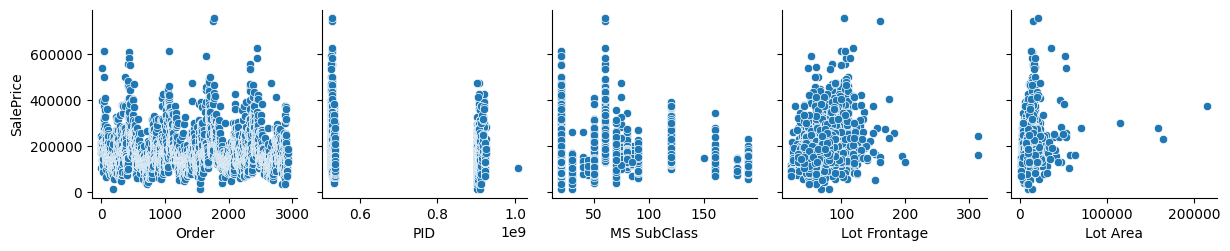

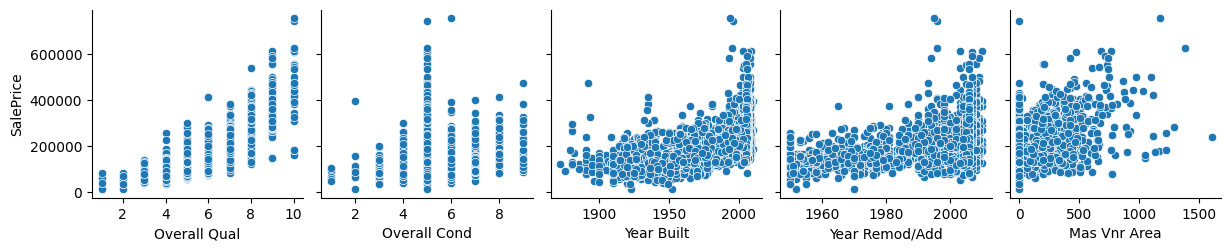

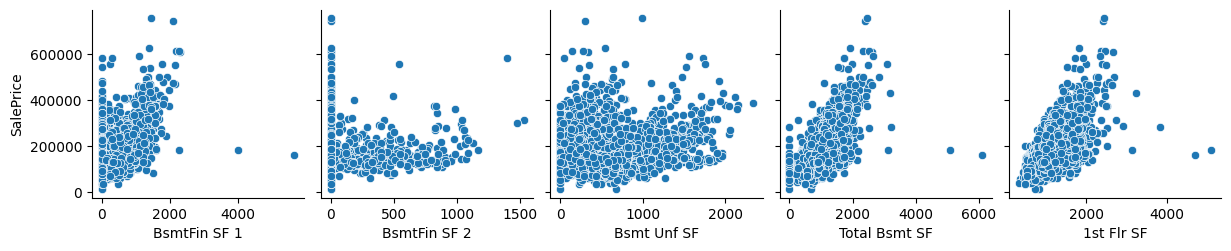

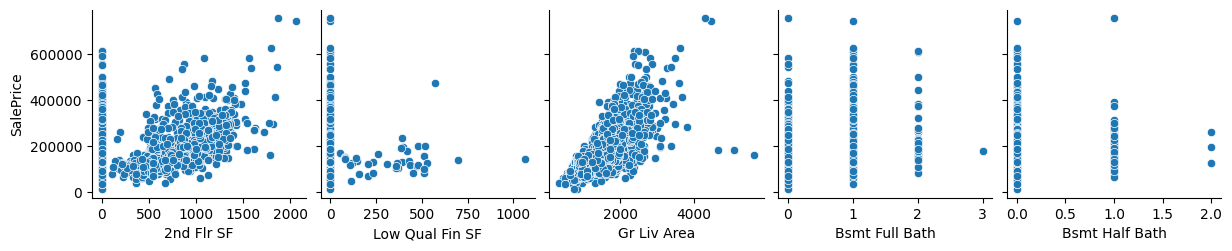

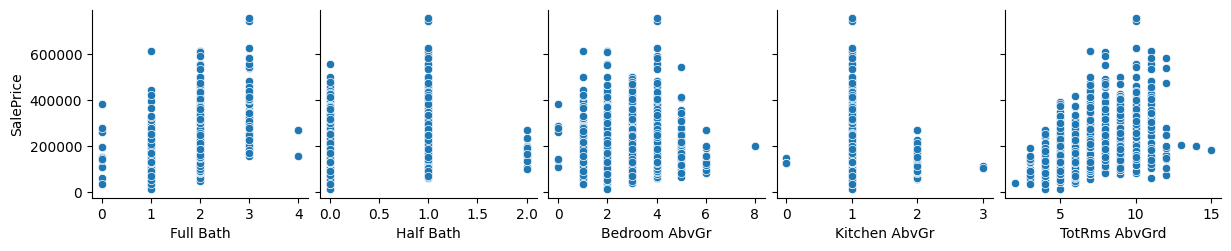

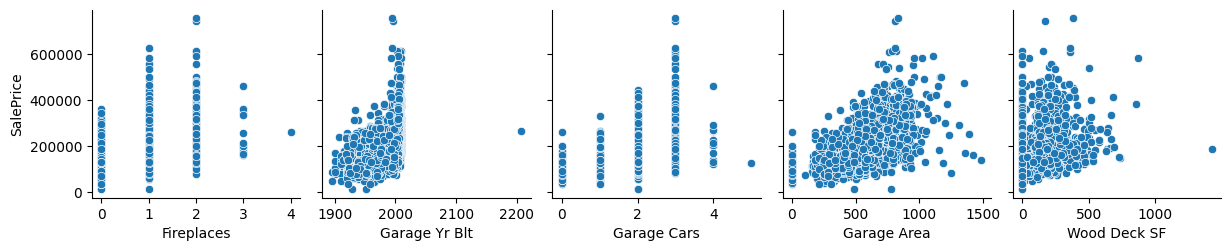

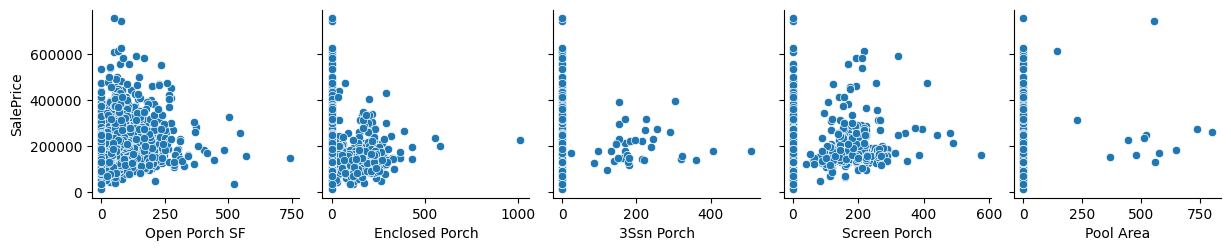

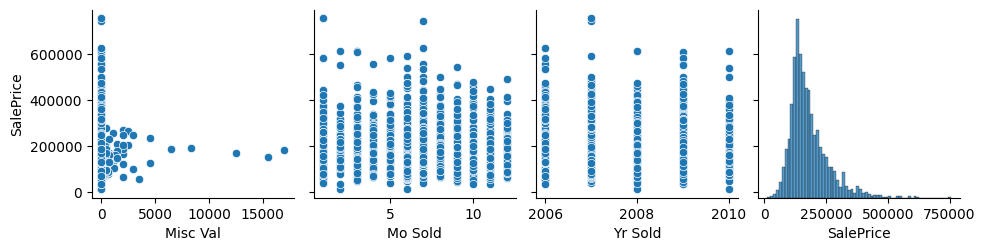

In [13]:
# use pair plots to visualize the correlation between features and target (SalePrice) 
# sns.pairplot(housing_num, x_vars=housing_num.columns, y_vars=['SalePrice'])
for i in range(0, len(housing_num.columns), 5):
    sns.pairplot(data=housing_num, x_vars=housing_num.columns[i:i+5], y_vars=['SalePrice'])

## Log Transformation
Some ML models assume the target is normally distributed. We can check this assumption using `sns.displot`

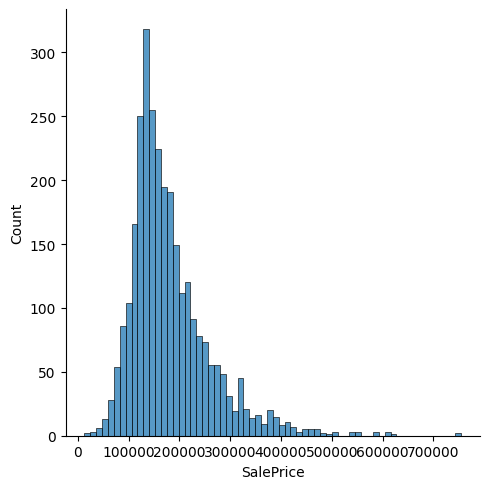

In [14]:
sns.displot(housing['SalePrice']);

## Skewness 
Longer tail on the right side - positive skew. This skewness is the measure of assymetry of the distibution and we can check it using `.skew()` function 

In [15]:
housing['SalePrice'].skew()

np.float64(1.743221853159165)

In the fairly distributed data the range of skewness is between -0.5 and 0.5, moderately distributed data has skewness between -0.5 and -1.0, or 0.5 and 1.0; highly skewed distribution is <-1.0 and 1.0<. In our case the skewness is 1.7 that means the distribution is highly skewed.

To make our data normally distributed we have several options
- log transform - `np.log()`
- square root transform - `np.sqrt()`
- Box-Cox transform - `scipy.stats.boxcox`

Skewness is -0.015354


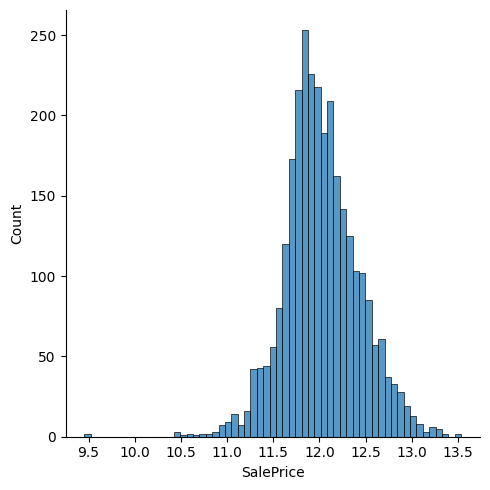

In [16]:
log_transformed=np.log(housing['SalePrice'])
sp_transformed=sns.displot(log_transformed)
print('Skewness is %f' % log_transformed.skew()) # now skewness should be well within the range

# Exercises

### Handling Duplicates
- First check whether our data contains any duplicates(hint: `.duplicated()` or `index.is_unique`)
- Then remove duplicates

In [ ]:
housing.duplicated().sum()

np.int64(1)

In [21]:
housing=housing.drop_duplicates()
print(housing.duplicated().sum(0))

0


C:\Users\user\AppData\Local\Temp\ipykernel_5924\3389800064.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print(housing.duplicated().sum(0))


### Handling missing values
- First detect missing values (`.isna()`, `.isnull()` etc.)
- Use `.sort_values()` to find worst offenders i.e most missing values
- Then handle those missing values: use `.dropna()`, `.drop()`, `.fillna()` and explain trade-offs

In [23]:
housing.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [24]:
missing=housing.isnull().sum().sort_values(ascending=False)
print(missing)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64


In [25]:
housing=housing.drop(columns=['Alley','PoolQC'])
num_cols=housing.select_dtypes(include=['int64','float64']).columns
housing[num_cols]=housing[num_cols].fillna(housing[num_cols].median())

KeyError: "['PoolQC'] not found in axis"

### Handling outliers
- Find outliers. You can use box plot or scatter plot. first use uni-variate analysis (using one variable) then use multi-variate analysis (two or more variables)
- With your own words explain how box plot works in markdown cell
- Would you keep or remove those outliers?
- Then perform bi-variate analysis of the two features: 'SalePrice' and 'GrLivArea', plot the scatter plot
- Find the indices of outliers appear in scatter plot and delete them using `.drop()`, then plot the scatter plot again
- Do the same with 'Lot Area' feature


### Feature Scaling
- When the values are in complete different scales (e.g. age and income) we perform feature scaling
- There are 2 ways of doing this:normalization (min-max scaling) and standardization. In normalization the data is rescaled so that it end up in the range [0,1]. In standardization the resulting distribution has zero variance. They are also calculated in different ways. Normalization: 
$\frac{x- x_{min}}{x_{max}-x_{min}}$ Standardization: $\frac{x-x_{mean}}{x_{std}}$ deviation. The functions we need are `MinMaxScalar` and `StandardScalar` from scikit-learn library
- But first try to write these functions yourself using numpy or pandas then you can import from scikit-learn
- print statistics before scaling and after scaling, explain the differences